# Success rate around the cue-removal / rotation tests

Success rate as a function of PROTOCOL DAY for each manipulation. The day axis is the
7-point sequence around each test:

    D-2  ->  D-1  ->  Baseline  ->  Test (removal)  ->  D+1  ->  D+2  ->  D+3

There are three manipulations, each on its own timeline: **tactile** cue removal,
**sound** cue removal, and **floor** rotation (odour). The figure is three subplots side
by side, one per manipulation, each showing success rate across those seven days with one
coloured line per mouse plus a black group-mean line.

Sessions are transcribed from Celia's test tables into `TEST_DETAIL` below. Notes:
- a day can pool several Bonsai sessions ("combine N sessions"); they repeat the day label.
- a session can be REUSED (one test's D+1 is the next test's D-2); it then appears under
  both (test, day) pairs and its trials count toward both curves. This is expected.
- MR and MbR run the block protocol, so their rows drop the ON (cue) trials (exclude_on).

Runs on the data PC against the test tree. See the CONFIRM notes in the setup cell.

In [7]:
# Initial setup
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_conduit.qc import qc_datastructure

# The test "before" days (D-2/D-1) are each mouse's last TRAINING sessions, which live
# under the Training tree, NOT Test. So load from the common BonsaiOutput parent (depth=3,
# <tree>/<mouseID>/<day>/<session>); include= still restricts to the TEST_DETAIL sessions,
# so scanning the sibling trees (Shaping etc.) costs only a directory walk, not extra loads.
ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput')

# Order of the session axis, shared by all three manipulations. These stay the internal
# join keys (they must match the day_label values in TEST_DETAIL), so DO NOT rename them.
TEST_DAY_ORDER = ('D-2', 'D-1', 'Baseline', 'Test', 'D+1', 'D+2', 'D+3')

# Display-only labels (what the figure prints; the keys above stay the join keys).
#   * the axis is framed as sessions relative to the test session T: D-+n -> 'Session T-+n'.
#   * the middle 'Test' tick is replaced PER PANEL with the manipulation that happened there
#     (TEST_EVENT_LABELS below); 'Session T' is only the fallback if a test isn't mapped.
#   * each manipulation gets its full name (TEST_TITLES) instead of the generic word "test".
SESSION_AXIS_LABELS = ('Session T-2', 'Session T-1', 'Baseline', 'Session T',
                       'Session T+1', 'Session T+2', 'Session T+3')
TEST_TITLES = {
    'tactile': 'Tactile cue removal',
    'sound': 'Sound cue removal',
    'floor': 'Floor rotation (odour scrambling)',
}
TEST_EVENT_LABELS = {                        # tick label at the T (manipulation) session
    'tactile': 'Tactile Cue Removal',
    'sound': 'Sound Cue Removal',
    'floor': 'Floor Rotation',
}

In [ ]:
# Test-session transcription (from Celia's pasted tables).
# {mouseID: {test: [(day_label, session, min_trial, exclude_on), ...]}}
#   * day_label  : one of TEST_DAY_ORDER. Repeat it for a combined (pooled) day.
#   * min_trial  : keep trial_index >= min_trial (the "X to end" rule).
#   * exclude_on : drop LED=='ON' cue trials (True for the block-protocol mice MR / MbR).
# Notes below flag source quirks (verified against the full tables): rows labelled
# "combine N" that actually list fewer sessions, and a few timelines that stop early.
# These reflect the source tables, not transcription loss.
TEST_DETAIL: dict[str, dict[str, list[tuple[str, str, int, bool]]]] = {
    'FL_M01569519': {                                    # tactile only
        'tactile': [
            ('D-2', '2026-05-13T161503Z', 24, False),
            ('D-1', '2026-05-14T165819Z', 24, False),
            ('Baseline', '2026-05-15T154239Z', 24, False),
            ('Test', '2026-05-15T155744Z', 2, False),
            ('D+1', '2026-05-16T190211Z', 24, False),
            ('D+2', '2026-05-18T110707Z', 24, False),
            ('D+3', '2026-05-19T123252Z', 24, False),
        ],
    },
    'FLR_M01569521': {                                   # tactile + sound (no floor)
        'tactile': [
            ('D-2', '2026-04-29T161826Z', 11, False),
            ('D-1', '2026-04-30T151438Z', 6, False),
            ('Baseline', '2026-05-01T165212Z', 11, False),
            ('Test', '2026-05-01T171522Z', 2, False),
            ('D+1', '2026-05-02T174538Z', 11, False),    # combine 2
            ('D+1', '2026-05-02T175834Z', 11, False),
            ('D+2', '2026-05-03T180126Z', 11, False),    # combine 2 (source: "maybe stop here, weird protocol afterward")
            ('D+2', '2026-05-03T180934Z', 11, False),
            ('D+3', '2026-05-04T160053Z', 11, False),
        ],
        'sound': [
            ('D-2', '2026-05-02T174538Z', 11, False),    # = tactile D+1 (reuse)
            ('D-2', '2026-05-02T175834Z', 11, False),
            ('D-1', '2026-05-03T180126Z', 11, False),    # = tactile D+2 (reuse)
            ('D-1', '2026-05-03T180934Z', 11, False),
            ('Baseline', '2026-05-04T160053Z', 11, False),  # = tactile D+3 (reuse)
            ('Test', '2026-05-04T163513Z', 2, False),
            ('D+1', '2026-05-05T171659Z', 11, False),    # combine 3
            ('D+1', '2026-05-05T173637Z', 2, False),
            ('D+1', '2026-05-05T174308Z', 6, False),
            ('D+2', '2026-05-06T161348Z', 11, False),
            ('D+3', '2026-05-06T180453Z', 11, False),
        ],
    },
    'FbR_M01569522': {                                   # tactile + sound + floor
        'tactile': [
            ('D-2', '2026-04-28T163449Z', 21, False),    # combine 3
            ('D-2', '2026-04-28T164540Z', 12, False),
            ('D-2', '2026-04-28T165257Z', 16, False),
            ('D-1', '2026-04-29T153239Z', 23, False),    # combine 2
            ('D-1', '2026-04-29T155431Z', 14, False),
            ('Baseline', '2026-04-30T170040Z', 11, False),   # min_trial was blank in the source table; confirmed 11 to end by Celia.
            ('Test', '2026-04-30T171128Z', 2, False),
            ('D+1', '2026-05-01T181050Z', 6, False),     # combine 2
            ('D+1', '2026-05-01T182520Z', 11, False),
            ('D+2', '2026-05-02T165009Z', 11, False),    # combine 2
            ('D+2', '2026-05-02T170316Z', 11, False),
            ('D+3', '2026-05-03T164101Z', 11, False),    # NOTE: labelled "combine 2" but source lists only this session
        ],
        'sound': [
            ('D-2', '2026-05-01T181050Z', 6, False),     # = tactile D+1
            ('D-2', '2026-05-01T182520Z', 11, False),
            ('D-1', '2026-05-02T165009Z', 11, False),    # = tactile D+2
            ('D-1', '2026-05-02T170316Z', 11, False),
            ('Baseline', '2026-05-03T164101Z', 11, False),  # = tactile D+3
            ('Test', '2026-05-03T170820Z', 2, False),
            ('D+1', '2026-05-04T175800Z', 11, False),    # NOTE: labelled "combine 3" but source lists only these two sessions
            ('D+1', '2026-05-04T181610Z', 6, False),
            ('D+2', '2026-05-06T153817Z', 11, False),    # combine 2
            ('D+2', '2026-05-06T172454Z', 11, False),
            ('D+3', '2026-05-12T182434Z', 24, False),
        ],
        'floor': [
            ('D-2', '2026-06-22T145508Z', 24, False),
            ('D-1', '2026-06-24T143728Z', 24, False),
            ('Baseline', '2026-06-29T135240Z', 24, False),
            ('Test', '2026-06-29T140917Z', 2, False),
            ('D+1', '2026-07-01T160341Z', 24, False),
            ('D+2', '2026-07-03T111750Z', 24, False),
            ('D+3', '2026-07-06T104800Z', 24, False),
        ],
    },
    'MbL_M01569517': {                                   # tactile + sound + floor
        'tactile': [
            ('D-2', '2026-05-28T154840Z', 24, False),
            ('D-1', '2026-05-29T155941Z', 24, False),
            ('Baseline', '2026-05-31T173901Z', 24, False),
            ('Test', '2026-05-31T175517Z', 2, False),
            ('D+1', '2026-06-02T111932Z', 24, False),
            ('D+2', '2026-06-04T095932Z', 24, False),
            ('D+3', '2026-06-06T125606Z', 24, False),
        ],
        'sound': [
            ('D-2', '2026-06-18T104906Z', 24, False),
            ('D-1', '2026-06-21T084325Z', 24, False),
            ('Baseline', '2026-06-23T100708Z', 24, False),
            ('Test', '2026-06-23T102442Z', 2, False),
            ('D+1', '2026-06-25T104906Z', 24, False),
            ('D+2', '2026-06-27T130156Z', 24, False),
            ('D+3', '2026-06-30T123717Z', 24, False),
        ],
        'floor': [
            ('D-2', '2026-06-27T130156Z', 24, False),    # = sound D+2 (reuse)
            ('D-1', '2026-06-30T123717Z', 24, False),    # = sound D+3 (reuse)
            ('Baseline', '2026-07-01T113346Z', 24, False),
            ('Test', '2026-07-01T115226Z', 2, False),    # combine 2
            ('Test', '2026-07-01T115912Z', 2, False),
            ('D+1', '2026-07-02T113845Z', 24, False),
            ('D+2', '2026-07-05T124734Z', 24, False),
            ('D+3', '2026-07-06T131636Z', 24, False),
            # Source floor table ends at D+2 (no D+3 row).
        ],
    },
    'MR_M01569515': {                                    # exclude_on throughout; sound/floor CUT OFF in source
        'tactile': [
            ('D-2', '2026-06-18T115150Z', 24, True),
            ('D-1', '2026-06-21T093349Z', 24, True),
            ('Baseline', '2026-06-23T110035Z', 24, True),
            ('Test', '2026-06-23T111711Z', 2, True),
            ('D+1', '2026-06-25T120231Z', 24, True),
            ('D+2', '2026-06-27T135645Z', 24, True),
            ('D+3', '2026-06-30T151336Z', 24, True),
        ],
        'sound': [
            ('D-2', '2026-06-25T120231Z', 24, True),     # = tactile D+1
            ('D-1', '2026-06-27T135645Z', 24, True),     # = tactile D+2
            ('Baseline', '2026-06-30T151336Z', 24, True),   # = tactile D+3
            ('Test', '2026-06-30T152955Z', 2, True),
            ('D+1', '2026-07-02T124156Z', 24, True),     # NOTE: labelled "combine 3" but source lists only this session; also = floor D-2
            # Source table ends here: MR has no sound D+2 / D+3 (later tests not tabulated).
        ],
        'floor': [
            ('D-2', '2026-07-02T124156Z', 24, True),     # = sound D+1
            # Source lists only floor D-2 for MR (its floor test is not tabulated further).
        ],
    },
    'MbR_M01569518': {                                   # exclude_on throughout
        'tactile': [
            ('D-2', '2026-06-06T112023Z', 24, True),     # NOTE: labelled "combine 3" but source lists only this session
            ('D-1', '2026-06-09T132359Z', 24, True),     # NOTE: labelled "combine 2" but source lists only this session
            ('Baseline', '2026-06-11T121616Z', 24, True),
            ('Test', '2026-06-11T123449Z', 2, True),
            ('D+1', '2026-06-13T122709Z', 24, True),     # NOTE: labelled "combine 2" but source lists only this session
            ('D+2', '2026-06-16T124607Z', 24, True),     # NOTE: labelled "combine 2" but source lists only this session
            ('D+3', '2026-06-18T124127Z', 24, True),     # NOTE: labelled "combine 2" but source lists only this session; also = sound D-2
        ],
        'sound': [
            ('D-2', '2026-06-18T124127Z', 24, True),     # = tactile D+3 (reuse)
            ('D-1', '2026-06-21T101916Z', 24, True),
            ('Baseline', '2026-06-23T120322Z', 24, True),
            ('Test', '2026-06-23T121822Z', 2, True),
            ('D+1', '2026-06-25T162955Z', 24, True),     # NOTE: labelled "combine 3" but source lists only this session; also = floor D-2
            ('D+2', '2026-06-27T145635Z', 24, True),     # NOTE: labelled "combine 2" but source lists only this session; also = floor D-1
            ('D+3', '2026-07-01T133745Z', 24, True),     # also = floor Baseline
        ],
        'floor': [
            ('D-2', '2026-06-25T162955Z', 24, True),     # = sound D+1
            ('D-1', '2026-06-27T145635Z', 24, True),     # = sound D+2
            ('Baseline', '2026-07-01T133745Z', 24, True),   # = sound D+3
            ('Test', '2026-07-01T135304Z', 2, True),
            ('D+1', '2026-07-02T142746Z', 24, True),
            ('D+2', '2026-07-05T134809Z', 24, True),
            ('D+3', '2026-07-06T140914Z', 24, True),
            # Source floor table ends at D+2 (no D+3 row).
        ],
    },
}

In [9]:
# Spec + filter helpers (mirror the training_filter pattern, kept local to this notebook).
def test_spec(detail=TEST_DETAIL):
    """Flatten TEST_DETAIL into a tidy per-session spec DataFrame (one row per session
    entry), adding a numeric `day_order` (1..7 along TEST_DAY_ORDER) for the x-axis."""
    order = {label: i + 1 for i, label in enumerate(TEST_DAY_ORDER)}
    rows = [
        {'mouseID': mouse, 'test': test, 'day_label': day_label,
         'day_order': order[day_label], 'session': session,
         'min_trial': min_trial, 'exclude_on': exclude_on}
        for mouse, tests in detail.items()
        for test, entries in tests.items()
        for (day_label, session, min_trial, exclude_on) in entries
    ]
    return pd.DataFrame.from_records(
        rows, columns=['mouseID', 'test', 'day_label', 'day_order',
                       'session', 'min_trial', 'exclude_on'])


def test_session_names(spec):
    """De-duplicated session names to pass as qc_datastructure(include=...)."""
    return list(dict.fromkeys(spec['session']))


def filter_test_trials(trials, spec, *, mouse_col='mouseID', session_col='session',
                       trial_index_col='trial_index', led_col='LED'):
    """Filter loaded trials by the per-(test, day) rules and tag each with its
    (test, day_label, day_order). A REUSED session joins to several (test, day) rows,
    so its trials are duplicated across those tests on purpose; keep trial_index >=
    min_trial and, where exclude_on, drop the LED=='ON' cue trials."""
    merged = trials.merge(spec, on=[mouse_col, session_col], how='inner')
    keep = merged[trial_index_col] >= merged['min_trial']
    keep &= ~(merged['exclude_on'] & (merged[led_col] == 'ON'))
    kept = merged[keep].sort_values(
        [mouse_col, 'test', 'day_order', session_col, trial_index_col]).reset_index(drop=True)
    kept['day_trial_index'] = kept.groupby([mouse_col, 'test', 'day_label']).cumcount() + 1
    return kept


def make_outcome_df(trials, outcome_filters, *, group_cols, outcome_col='outcome'):
    """Per-group outcome counts and proportions (n_<name>, prop_<name>)."""
    group_cols = list(group_cols)
    out = trials.groupby(group_cols).size().rename('n_total').reset_index()
    for name, outcomes in outcome_filters.items():
        counts = (trials[trials[outcome_col].isin(outcomes)]
                  .groupby(group_cols).size().rename(f'n_{name}').reset_index())
        out = out.merge(counts, on=group_cols, how='left')
        out[f'n_{name}'] = out[f'n_{name}'].fillna(0).astype(int)
        out[f'prop_{name}'] = out[f'n_{name}'] / out['n_total']
    return out

In [10]:
# Figure | Success rate vs session, one subplot per manipulation.
DEFAULT_MOUSE_COLOURS = {
    'FLR_M01569521': '#f994b1', 'FbR_M01569522': '#e53592', 'FL_M01569519': '#950041',
    'MR_M01569515': '#73a9cf', 'MbR_M01569518': '#2e7ebc', 'MbL_M01569517': '#004cd9',
}


def plot_test_panels(trials, *, tests=('tactile', 'sound', 'floor'),
                     mouse_colours=DEFAULT_MOUSE_COLOURS, mouse_col='mouseID',
                     test_col='test', order_col='day_order', chance_level=1.0 / 18.0,
                     line_alpha=0.3, marker_alpha=0.85, mean_colour='black',
                     figsize_per_panel=(4.6, 4.4)):
    """One subplot per manipulation: success rate across the 7 sessions, a coloured line per
    mouse plus a black group-mean line and the theoretical-chance line. Only manipulations
    present in `trials` are drawn; each mouse is reindexed onto all 7 sessions so gaps show
    as breaks. A shaded band brackets the baseline -> manipulation component of each test."""
    present = [t for t in tests if t in set(trials[test_col])]
    positions = list(range(1, len(TEST_DAY_ORDER) + 1))
    baseline_pos = TEST_DAY_ORDER.index('Baseline') + 1
    test_pos = TEST_DAY_ORDER.index('Test') + 1
    fig, axes = plt.subplots(1, len(present),
                             figsize=(figsize_per_panel[0] * len(present), figsize_per_panel[1]),
                             sharey=True, squeeze=False)
    axes = axes[0]
    for ax, test in zip(axes, present):
        sub = trials[trials[test_col] == test]
        summary = make_outcome_df(sub, {'success': ['Success']}, group_cols=(mouse_col, order_col))
        # Light transparent-grey band with dashed edges marking the baseline/test component
        # (the baseline run and the manipulation run, which sit on the same protocol day).
        ax.axvspan(baseline_pos, test_pos, facecolor=(0.5, 0.5, 0.5, 0.15),
                   edgecolor=(0.3, 0.3, 0.3, 0.85), linewidth=1.2, linestyle='--', zorder=0)
        mice = [m for m in mouse_colours if m in set(sub[mouse_col])]
        for mouse in mice:
            series = (summary[summary[mouse_col] == mouse]
                      .set_index(order_col).reindex(positions)['prop_success'])
            ax.plot(positions, series.values, color=mouse_colours[mouse], alpha=line_alpha,
                    linewidth=4, solid_capstyle='round', zorder=1)
            ax.scatter(positions, series.values, color=mouse_colours[mouse], alpha=marker_alpha,
                       edgecolor='black', linewidth=0.4, zorder=2, label=mouse)
        group_mean = summary.groupby(order_col)['prop_success'].mean().reindex(positions)
        ax.plot(positions, group_mean.values, color=mean_colour, linewidth=2.5, marker='o',
                zorder=3, label='Group mean')
        ax.axhline(chance_level, linestyle='--', color='0.4', linewidth=1, zorder=0)
        ax.set_title(TEST_TITLES.get(test, test))
        # Per-panel tick labels: the T (manipulation) session names what actually happened.
        labels = list(SESSION_AXIS_LABELS)
        labels[test_pos - 1] = TEST_EVENT_LABELS.get(test, labels[test_pos - 1])
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0, 1)
    axes[0].set_ylabel('Success rate')
    # Legend from every mouse present across ALL panels (a plain axes.legend() would only
    # capture the last panel's mice, e.g. the 3 floor mice).
    from matplotlib.lines import Line2D
    all_mice = [m for m in mouse_colours if m in set(trials[mouse_col])]
    handles = [Line2D([0], [0], color=mouse_colours[m], marker='o', linestyle='-',
                      markeredgecolor='black', markeredgewidth=0.4, label=m) for m in all_mice]
    handles.append(Line2D([0], [0], color=mean_colour, marker='o', linewidth=2.5, label='Group mean'))
    axes[-1].legend(handles=handles, fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
    fig.supxlabel('T = test / manipulation session')
    fig.suptitle('Success rate around each manipulation (cue removal / floor rotation)')
    fig.tight_layout()
    return fig, axes

In [11]:
# Session selection + load. Load only the sessions listed in TEST_DETAIL, then filter.
spec = test_spec()
print(f'{spec["session"].nunique()} unique sessions across '
      f'{spec["mouseID"].nunique()} mice; tests present: '
      f'{sorted(spec["test"].unique())}')

datastructure = qc_datastructure(
    root=ROOT,
    depth=3,                                              # <tree>/<mouseID>/<day>/<session>
    level_names=('tree', 'mouseID', 'day'),
    streams=('events', 'nosepoke', 'soundcard', 'session_settings'),   # trial table only
    include=test_session_names(spec),
)
result = datastructure.load()
trials = result['trials']
trials_filtered = filter_test_trials(trials, spec)
trials_filtered

91 unique sessions across 6 mice; tests present: ['floor', 'sound', 'tactile']


,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,...,session,tree,mouseID,day,test,day_label,day_order,min_trial,exclude_on,day_trial_index
0,11,21694.856992,21727.257504,21722.236992,21694.856992,21722.236992,21722.236992,21727.257504,27.380000,5.020512,...,2026-05-02T174538Z,Test,FLR_M01569521,Day2-3NoTactileCue,sound,D-2,1,11,False,1
1,12,21727.257504,21738.125984,21735.088000,21727.257504,21735.088000,21735.088000,21738.125984,7.830496,3.037984,...,2026-05-02T174538Z,Test,FLR_M01569521,Day2-3NoTactileCue,sound,D-2,1,11,False,2
2,13,21738.125984,21760.357504,21755.337984,21738.125984,21755.337984,21755.337984,21760.357504,17.212000,5.019520,...,2026-05-02T174538Z,Test,FLR_M01569521,Day2-3NoTactileCue,sound,D-2,1,11,False,3
3,14,21760.357504,21789.754976,21784.737984,21760.357504,21784.737984,21784.737984,21789.754976,24.380480,5.016992,...,2026-05-02T174538Z,Test,FLR_M01569521,Day2-3NoTactileCue,sound,D-2,1,11,False,4
4,15,21789.754976,21804.904000,21799.889984,21789.754976,21799.889984,21799.889984,21804.904000,10.135008,5.014016,...,2026-05-02T174538Z,Test,FLR_M01569521,Day2-3NoTactileCue,sound,D-2,1,11,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6514,103,13676.755488,13693.368000,13690.621984,13676.755488,13690.621984,13690.621984,13693.368000,13.866496,2.746016,...,2026-06-18T124127Z,Test,MbR_M01569518,Day4-5NoTactileCue,tactile,D+3,7,24,True,77
6515,104,13693.368000,13713.729984,13710.670976,13693.368000,13710.670976,13710.670976,13713.729984,17.302976,3.059008,...,2026-06-18T124127Z,Test,MbR_M01569518,Day4-5NoTactileCue,tactile,D+3,7,24,True,78
6516,105,13713.729984,13727.907488,13724.570976,13713.729984,13724.570976,13724.570976,13727.907488,10.840992,3.336512,...,2026-06-18T124127Z,Test,MbR_M01569518,Day4-5NoTactileCue,tactile,D+3,7,24,True,79
6517,106,13727.907488,13743.238976,13738.220992,13727.907488,13738.220992,13738.220992,13743.238976,10.313504,5.017984,...,2026-06-18T124127Z,Test,MbR_M01569518,Day4-5NoTactileCue,tactile,D+3,7,24,True,80


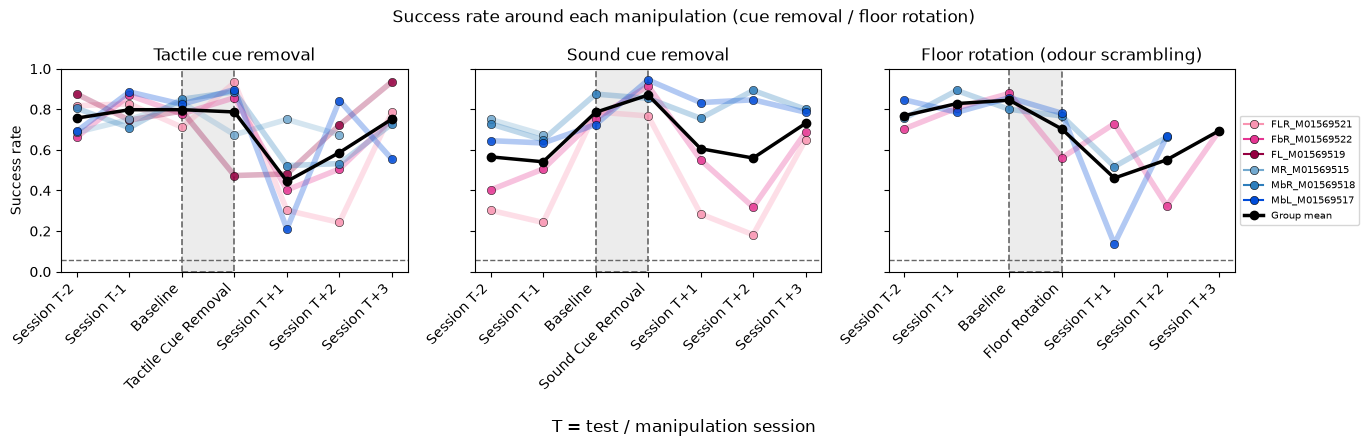

In [12]:
# Render the figure (all mice pooled per test).
fig, axes = plot_test_panels(trials_filtered)
plt.show()